In [1]:
import geopandas as gpd
from shapely.geometry import LineString
from argopy import ArgoIndex
import matplotlib.pyplot as plt
import contextily as cx
import argopy
import gsw
import copernicusmarine
import os
import xarray as xr
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import numpy as np

/home/adrian/spack/opt/spack/linux-skylake/miniconda3-24.3.0-k6rvhdk2bfkz6czoll5ls2digtuckfxo/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Obtención de la boyas argo con los datos de hace siete días hasta hoy

In [2]:
# ------------------------------------------------------------------
# Caja espacio-temporal: [lon_min, lon_max, lat_min, lat_max,
#                          pres_min, pres_max, fecha_min, fecha_max]
# ------------------------------------------------------------------

# BOX = [-14.0, -4.5, 38.0, 46.0, 0, 4000, "2026-06-15", "2026-07-01"]

# fetcher = argopy.DataFetcher()  # por defecto: src='erddap', mode='standard', ds='phy'
# fetcher = fetcher.region(BOX)



# Fechas para atras desde hoy
fecha_hoy = datetime.now().strftime("%Y-%m-%d")
fecha_hace_una_semana = (datetime.now() - timedelta(days=7)).strftime("%Y-%m-%d")

BOX = [-14.0, -4.5, 38.0, 46.0, 0, 4000, fecha_hace_una_semana, fecha_hoy]

fetcher = argopy.DataFetcher()
fetcher = fetcher.region(BOX)



ds = fetcher.to_xarray()
df = ds.to_dataframe().reset_index()

# Columnas relevantes (hay más: QC, _ADJUSTED, etc. en modo 'standard')
cols = ["PLATFORM_NUMBER", "CYCLE_NUMBER", "TIME", "LATITUDE", "LONGITUDE",
        "PRES", "TEMP", "PSAL"]
df = df[cols].sort_values(["PLATFORM_NUMBER", "TIME", "PRES"])

print(f"Filas (boya-ciclo-profundidad): {len(df)}")
print(f"Boyas distintas: {df.PLATFORM_NUMBER.nunique()}")

display(df[['PLATFORM_NUMBER', 'CYCLE_NUMBER', 'TIME', 'LATITUDE', 'LONGITUDE']].drop_duplicates())

# De tus columnas PRES, TEMP, PSAL, LATITUDE, LONGITUDE:
df['SA'] = gsw.SA_from_SP(df['PSAL'], df['PRES'], df['LONGITUDE'], df['LATITUDE'])  # Salinidad Absoluta
df['CT'] = gsw.CT_from_t(df['SA'], df['TEMP'], df['PRES'])                                # Temperatura Conservativa
df['rho'] = gsw.rho(df['SA'], df['CT'], df['PRES'])                                              # Densidad (kg/m³)
sigma0 = gsw.sigma0(df['SA'], df['CT'])                                                    # Densidad potencial referida a 0 dbar
N2, p_mid = gsw.Nsquared(df['SA'], df['CT'], df['PRES'])                                  # Frecuencia de Brunt-Väisälä

# Un punto por perfil (la posición no varía con PRES)
df_surf = df.sort_values("PRES").groupby(["PLATFORM_NUMBER", "CYCLE_NUMBER"]).first().reset_index()

gdf = gpd.GeoDataFrame(
    df_surf,
    geometry=gpd.points_from_xy(df_surf.LONGITUDE, df_surf.LATITUDE),
    crs="EPSG:4326",
).to_crs(epsg=3857)

df = df.sort_values(["PLATFORM_NUMBER", "CYCLE_NUMBER", "PRES"])

df["rho_columna_superior"] = (
    df.groupby(["PLATFORM_NUMBER", "CYCLE_NUMBER"])["rho"]
    .transform(lambda x: x.expanding().mean().shift(1)).fillna(df['rho'])
)

df['z_metros'] = 10000*df['PRES']/(df['rho_columna_superior'] * 9.81)

df.drop(['SA', 'CT'], inplace = True, axis = 1)
df

Filas (boya-ciclo-profundidad): 2458
Boyas distintas: 7


,PLATFORM_NUMBER,CYCLE_NUMBER,TIME,LATITUDE,LONGITUDE
1257,1902726,60,2026-07-02 14:06:58,44.130230,-9.939110
2363,1902809,29,2026-07-07 14:30:00,45.917000,-8.368000
967,2903801,27,2026-07-02 05:37:20,44.095072,-9.794478
1065,5906997,27,2026-07-02 05:48:00,38.519265,-10.689143
0,6902887,78,2026-07-01 08:39:00,39.632453,-13.125322
2266,6990667,71,2026-07-04 20:36:00,39.506483,-12.832905
1162,7901143,92,2026-07-02 11:40:20,41.956445,-10.590150


,PLATFORM_NUMBER,CYCLE_NUMBER,TIME,LATITUDE,LONGITUDE,PRES,TEMP,PSAL,rho,rho_columna_superior,z_metros
1257,1902726,60,2026-07-02 14:06:58,44.130230,-9.93911,0.960000,19.198000,35.601002,1025.437585,1025.437585,0.954318
1258,1902726,60,2026-07-02 14:06:58,44.130230,-9.93911,2.080000,19.202999,35.598999,1025.439669,1025.437585,2.067688
1259,1902726,60,2026-07-02 14:06:58,44.130230,-9.93911,3.080000,19.205000,35.601002,1025.445060,1025.438627,3.061766
1260,1902726,60,2026-07-02 14:06:58,44.130230,-9.93911,4.000000,19.202999,35.599998,1025.448838,1025.440771,3.976312
1261,1902726,60,2026-07-02 14:06:58,44.130230,-9.93911,5.080000,19.202999,35.599998,1025.453566,1025.442788,5.049906
...,...,...,...,...,...,...,...,...,...,...,...
1252,7901143,92,2026-07-02 11:40:20,41.956445,-10.59015,1887.900024,4.906000,35.169998,1036.399983,1030.829440,1866.909071
1253,7901143,92,2026-07-02 11:40:20,41.956445,-10.59015,1912.699951,4.786000,35.153000,1036.516293,1030.890654,1891.321014
1254,7901143,92,2026-07-02 11:40:20,41.956445,-10.59015,1937.800049,4.601000,35.124001,1036.634758,1030.951803,1916.026811
1255,7901143,92,2026-07-02 11:40:20,41.956445,-10.59015,1962.599976,4.487000,35.110001,1036.752279,1031.012910,1940.433143


Plot de las posiciones en la horizontal de las boyas argo

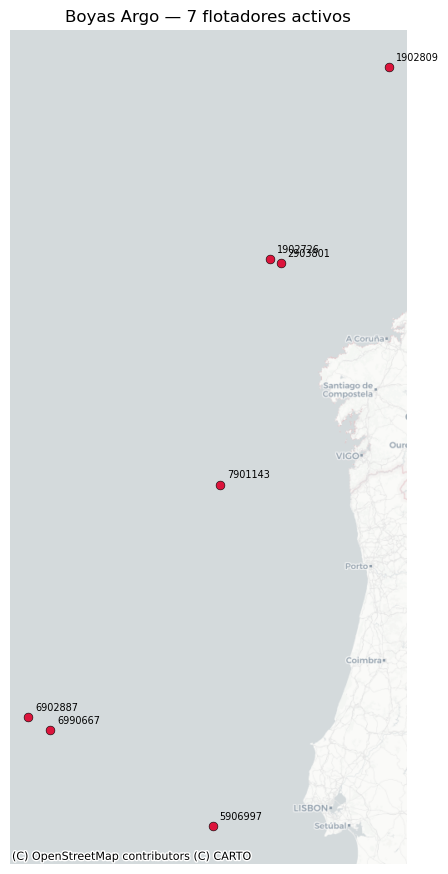

In [3]:
fig, ax = plt.subplots(figsize=(9, 9))
gdf.plot(ax=ax, color="crimson", markersize=40, edgecolor="black", linewidth=0.4, zorder=2)
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
ax.set_axis_off()
ax.set_title(f"Boyas Argo — {df_surf.PLATFORM_NUMBER.nunique()} flotadores activos")
fig.tight_layout()

for _, row in gdf.iterrows():
    ax.annotate(
        str(row["PLATFORM_NUMBER"]),
        xy=(row.geometry.x, row.geometry.y),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=7,
        color="black",
    )

IDs y numero de ciclo de las boyas en el área (misma área que el modelo ROMS de MeteoGalicia)

In [4]:

print("Boyas y sus ciclos desde hace una semana hasta hoy")

# Obtenemos las combinaciones únicas de boya y ciclo con su fecha de registro
opciones = df[['PLATFORM_NUMBER', 'CYCLE_NUMBER', 'TIME']].drop_duplicates(subset=['PLATFORM_NUMBER', 'CYCLE_NUMBER'])

for _, row in opciones.sort_values(['PLATFORM_NUMBER', 'CYCLE_NUMBER']).iterrows():
    fecha_str = pd.to_datetime(row['TIME']).strftime('%Y-%m-%d %H:%M')
    print(f"ID Boya: {row['PLATFORM_NUMBER']} | Ciclo: {row['CYCLE_NUMBER']} | Fecha: {fecha_str}")

Boyas y sus ciclos desde hace una semana hasta hoy
ID Boya: 1902726 | Ciclo: 60 | Fecha: 2026-07-02 14:06
ID Boya: 1902809 | Ciclo: 29 | Fecha: 2026-07-07 14:30
ID Boya: 2903801 | Ciclo: 27 | Fecha: 2026-07-02 05:37
ID Boya: 5906997 | Ciclo: 27 | Fecha: 2026-07-02 05:48
ID Boya: 6902887 | Ciclo: 78 | Fecha: 2026-07-01 08:39
ID Boya: 6990667 | Ciclo: 71 | Fecha: 2026-07-04 20:36
ID Boya: 7901143 | Ciclo: 92 | Fecha: 2026-07-02 11:40


Boya y ciclo a seleccionar:

In [5]:
MI_BOYA = 6902887
MI_CICLO = 78

# Seleccionamos el tamaño de la matriz para plotear, N x N
N = 1              # IMPORTANTE SIEMPRE IMPAR
paso_grados = 0.25 # incremendo en grados


Añadir 0.25 de distancia para hacer matriz 3x3 puntos


Plot de los perfiles de la boya seleccionada

Cargando datos de Boya: 6902887 | Ciclo: 78
Fecha del perfil: 2026-07-01 08:39
Guardado en: graficos_validacion/boya_6902887/ciclo_78/perfil_boya_argo.png


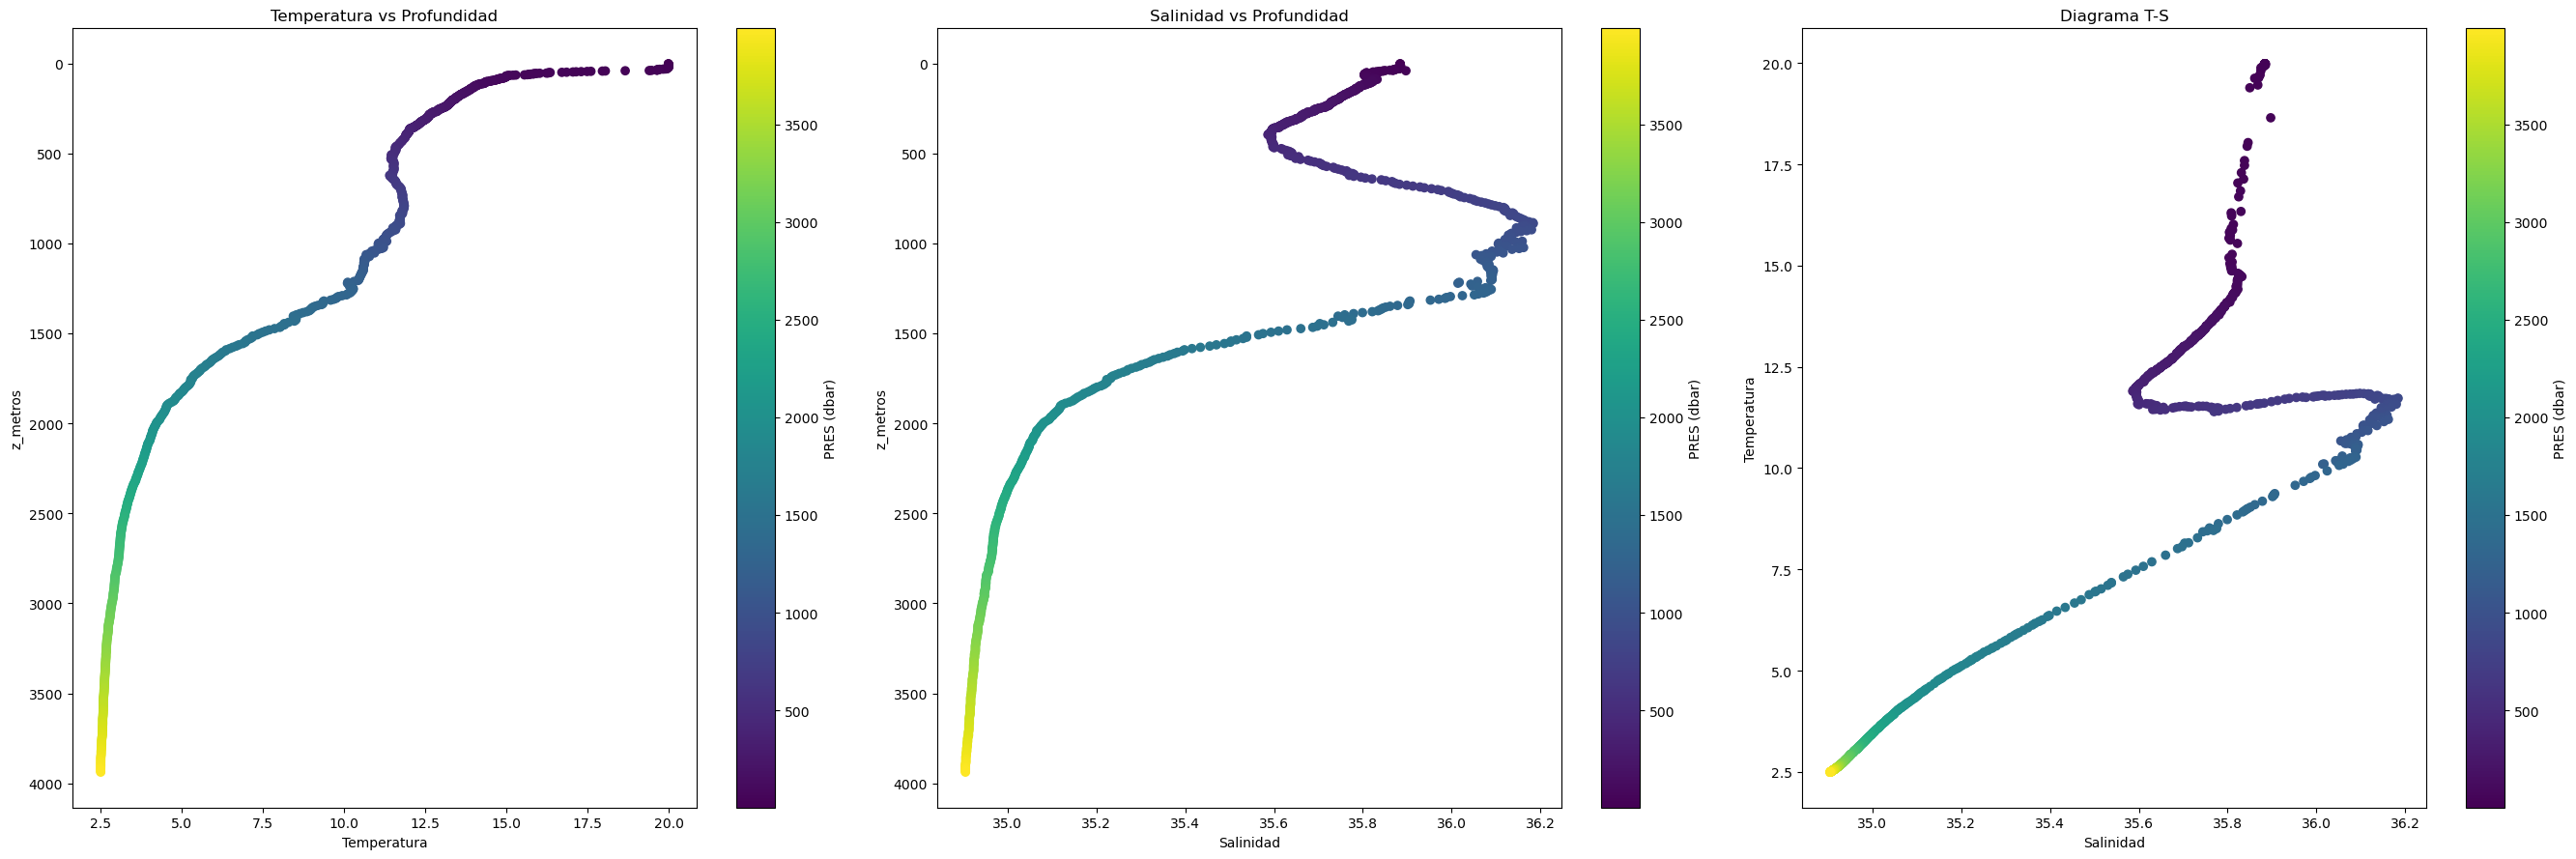

In [6]:
perfil = df[(df['PLATFORM_NUMBER'] == MI_BOYA) & (df['CYCLE_NUMBER'] == MI_CICLO)]

# Control de errores
if perfil.empty:
    print(f"No existen datos para la Boya {MI_BOYA} en el Ciclo {MI_CICLO}.")
    print("Por favor, revisa el listado de opciones e introduce una combinación válida.")
else:
    max_prof_boya = perfil['z_metros'].max()
    z_grid_uniforme = np.linspace(0, max_prof_boya, 100)

    print(f"Cargando datos de Boya: {MI_BOYA} | Ciclo: {MI_CICLO}")
    print(f"Fecha del perfil: {pd.to_datetime(perfil['TIME'].iloc[0]).strftime('%Y-%m-%d %H:%M')}")

    ruta_carpeta = f"graficos_validacion/boya_{MI_BOYA}/ciclo_{MI_CICLO}"
    os.makedirs(ruta_carpeta, exist_ok=True)

    fig, ax = plt.subplots(1, 3, figsize=(27, 9))

    # subplot 1
    ax[0].set_title("Temperatura vs Profundidad")
    sc = ax[0].scatter(perfil['TEMP'], perfil['z_metros'], 
                       c=perfil['PRES'], cmap='viridis',
                       marker='o')
    fig.colorbar(sc, ax=ax[0], label='PRES (dbar)')
    ax[0].set_xlabel('Temperatura')
    ax[0].set_ylabel('z_metros')
    ax[0].invert_yaxis()  # La profundidad aumenta hacia abajo

    # subplot 2
    ax[1].set_title("Salinidad vs Profundidad")
    sc = ax[1].scatter(perfil['PSAL'], perfil['z_metros'],
                       c=perfil['PRES'], cmap='viridis',
                       marker='o')
    fig.colorbar(sc, ax=ax[1], label='PRES (dbar)')
    ax[1].set_xlabel('Salinidad')
    ax[1].set_ylabel('z_metros')
    ax[1].invert_yaxis()  # La profundidad aumenta hacia abajo

    # subplot
    ax[2].set_title("Diagrama T-S")
    sc = ax[2].scatter(perfil['PSAL'], perfil['TEMP'],
                       c=perfil['PRES'], cmap='viridis',
                       marker='o')
    fig.colorbar(sc, ax=ax[2], label='PRES (dbar)')
    ax[2].set_xlabel('Salinidad')
    ax[2].set_ylabel('Temperatura')

    fig.tight_layout()
    
    ruta_guardado = f"{ruta_carpeta}/perfil_boya_argo.png"
    plt.savefig(ruta_guardado, dpi=300, bbox_inches='tight')
    print(f"Guardado en: {ruta_guardado}")
    
    plt.show()

Lectura del ROMS de MeteoGalicia en la fecha del ciclo

In [7]:
fecha_boya = pd.to_datetime(perfil['TIME'].iloc[0])
lat_boya = perfil['LATITUDE'].iloc[0]
lon_boya = perfil['LONGITUDE'].iloc[0]

print(f"Boya seleccionada - Fecha: {fecha_boya.strftime('%Y-%m-%d %H:%M')}")
print(f"Posición de la boya - Lat: {lat_boya:.4f}, Lon: {lon_boya:.4f}\n")

ds_roms = None

# Probamos desde el día de la boya hacia atrás
for dias_atras in range(5):
    fecha_intento = fecha_boya - timedelta(days=dias_atras)
    fecha_inicio_str = fecha_intento.strftime("%Y%m%d")

    fecha_fin = fecha_intento + timedelta(days=1)
    fecha_fin_str = fecha_fin.strftime("%Y%m%d")
    
    opendap_url = (
        f"https://thredds-meteo.cesga.es/thredds/dodsC/ROMS/ROMS_RAW_output/"
        f"{fecha_inicio_str}/00/ocean_history_a{fecha_inicio_str}_{fecha_fin_str}.nc"
    )
    
    print(f"Conectando al ROMS del {fecha_inicio_str}...")
    
    try:
        # Intentamos abrir los metadatos de la URL
        ds_intento = xr.open_dataset(opendap_url, engine='netcdf4')
        
        # Verificamos si la fecha de la boya cae dentro del rango de tiempo de este archivo
        time_min = pd.to_datetime(ds_intento['ocean_time'].values.min())
        time_max = pd.to_datetime(ds_intento['ocean_time'].values.max())
        
        if time_min <= fecha_boya <= time_max:
            print(f"Conexión OpenDAP establecida")
            print(f"El archivo cubre desde el {time_min.strftime('%Y-%m-%d')} hasta el {time_max.strftime('%Y-%m-%d')}")
            ds_roms = ds_intento
            break  # Rompemos el bucle, ya tenemos el archivo correcto
        else:
            print(f"Archivo encontrado pero la fecha de la boya está fuera de rango ({time_min.strftime('%Y-%m-%d')} a {time_max.strftime('%Y-%m-%d')}).")
            ds_intento.close()
            
    except Exception as e:
        # Si da 404 o error de red, el bucle continúa al siguiente día hacia atrás
        print(f"404, not Found")


print("-" * 80)
if ds_roms is None:
    print("ERROR: No se encontró ningún run del modelo ROMS en el catálogo THREDDS que cubra la fecha de esta boya.")
else:
    print("Variables listas para el análisis.")
    display(ds_roms)

Boya seleccionada - Fecha: 2026-07-01 08:39
Posición de la boya - Lat: 39.6325, Lon: -13.1253

Conectando al ROMS del 20260701...
Conexión OpenDAP establecida
El archivo cubre desde el 2026-07-01 hasta el 2026-07-02
--------------------------------------------------------------------------------
Variables listas para el análisis.


<xarray.Dataset> Size: 6GB
Dimensions:         (tracer: 2, boundary: 4, s_rho: 41, s_w: 42, eta_rho: 401,
                     xi_rho: 476, eta_u: 401, xi_u: 475, eta_v: 400, xi_v: 476,
                     eta_psi: 400, xi_psi: 475, ocean_time: 25)
Coordinates:
  * s_rho           (s_rho) float64 328B -0.9878 -0.9634 ... -0.03659 -0.0122
  * s_w             (s_w) float64 336B -1.0 -0.9756 -0.9512 ... -0.02439 0.0
    lon_rho         (eta_rho, xi_rho) float64 2MB ...
    lat_rho         (eta_rho, xi_rho) float64 2MB ...
    lon_u           (eta_u, xi_u) float64 2MB ...
    lat_u           (eta_u, xi_u) float64 2MB ...
    lon_v           (eta_v, xi_v) float64 2MB ...
    lat_v           (eta_v, xi_v) float64 2MB ...
    lon_psi         (eta_psi, xi_psi) float64 2MB ...
    lat_psi         (eta_psi, xi_psi) float64 2MB ...
  * ocean_time      (ocean_time) datetime64[ns] 200B 2026-07-01 ... 2026-07-02
Dimensions without coordinates: tracer, boundary, eta_rho, xi_rho, eta_u, xi_u,
                                eta_v, xi_v, eta_psi, xi_psi
Data variables: (12/99)
    ntimes          int32 4B ...
    ndtfast         int32 4B ...
    dt              float64 8B ...
    dtfast          float64 8B ...
    dstart          datetime64[ns] 8B ...
    nHIS            int32 4B ...
    ...              ...
    v               (ocean_time, s_rho, eta_v, xi_v) float32 781MB ...
    u_eastward      (ocean_time, s_rho, eta_rho, xi_rho) float32 783MB ...
    v_northward     (ocean_time, s_rho, eta_rho, xi_rho) float32 783MB ...
    temp            (ocean_time, s_rho, eta_rho, xi_rho) float32 783MB ...
    salt            (ocean_time, s_rho, eta_rho, xi_rho) float32 783MB ...
    AKv             (ocean_time, s_w, eta_rho, xi_rho) float32 802MB ...
Attributes: (12/36)
    file:                            ocean_history_a20260701_20260702.nc
    format:                          netCDF-3 64bit offset file
    Conventions:                     CF-1.4, SGRID-0.3
    type:                            ROMS/TOMS history file
    title:                           Operational Ocean Forecast for Northern ...
    var_info:                        varinfo.yaml
    ...                              ...
    tiling:                          008x008
    history:                         ROMS/TOMS, Version 4.2, Thursday - July ...
    ana_file:                        ROMS/Functionals/ana_btflux.h
    CPP_options:                     ROMSv2024-METEO, ADD_FSOBC, ADD_M2OBC, A...
    DODS_EXTRA.Unlimited_Dimension:  ocean_time
    EXTRA_DIMENSION.N:               41

Obtenemos la temperatura y salinidad en ese punto en el modelo ROMS

In [8]:
assert N % 2 != 0, "¡Error analítico! N debe ser impar para garantizar un centro geométrico absoluto."
centro = N // 2

# Buscamos el instante de tiempo más cercano
ocean_time = ds_roms['ocean_time'].values
target_time = np.datetime64(fecha_boya)

# Buscamos el índice temporal con la diferencia absoluta mínima
time_idx = np.argmin(np.abs(ocean_time - target_time))
fecha_modelo_detectada = pd.to_datetime(ocean_time[time_idx])

print("COINCIDENCIA TEMPORAL")
print(f"Fecha/Hora de la boya:  {fecha_boya.strftime('%Y-%m-%d %H:%M')}")
print(f"Fecha/Hora del modelo: {fecha_modelo_detectada.strftime('%Y-%m-%d %H:%M')}\n")
print("-" * 80)

# Extracción de perfiles asociados a la boya en malla curvilínea
lat_roms = ds_roms['lat_rho'].values
lon_roms = ds_roms['lon_rho'].values

# Generación dinámica de desplazamientos espaciales según el tamaño N elegido
# Filas: De arriba a abajo decrece la latitud (Norte [+] a Sur [-])
desplazamientos_lat = [(centro - fila) * paso_grados for fila in range(N)]
# Columnas: De izquierda a derecha crece la longitud (Oeste [-] a Este [+])
desplazamientos_lon = [(columna - centro) * paso_grados for columna in range(N)]

# Contenedor dinámico universal para los N x N puntos geográficos
resultados_roms_matriz = {}

print(f"COINCIDENCIA ESPACIAL PARA LOS {N*N} PUNTOS DE LA MATRIZ ({N}x{N}):")

# Iteramos dinámicamente sobre el rango N de filas y columnas
for eta_grid in range(N):
    for xi_grid in range(N):
        
        d_lat = desplazamientos_lat[eta_grid]
        d_lon = desplazamientos_lon[xi_grid]
        
        # Coordenadas geográficas teóricas del punto vecino actual
        lat_objetivo = lat_boya + d_lat
        lon_objetivo = lon_boya + d_lon

        # Calculamos la distancia euclídea al cuadrado en la malla curvilínea
        dist_matriz = (lat_roms - lat_objetivo)**2 + (lon_roms - lon_objetivo)**2

        # Encontramos los índices bidimensionales (eta, xi) del valor mínimo de distancia
        eta_idx, xi_idx = np.unravel_index(np.argmin(dist_matriz), dist_matriz.shape)

        # Extraemos la columna vertical completa de Temperatura ('temp') y Salinidad ('salt')
        roms_temp_perfil = ds_roms['temp'].isel(ocean_time=time_idx, eta_rho=eta_idx, xi_rho=xi_idx).values
        roms_salt_perfil = ds_roms['salt'].isel(ocean_time=time_idx, eta_rho=eta_idx, xi_rho=xi_idx).values

        # Pasamos de niveles sigma a profundidad en metros (Ecuaciones ROMS)
        h = ds_roms['h'].isel(eta_rho=eta_idx, xi_rho=xi_idx).values      # Profundidad del fondo batimétrico
        hc = ds_roms['hc'].values                                         # Profundidad crítica de corte
        Cs_r = ds_roms['Cs_r'].values                                     # Coeficiente de estiramiento vertical
        s_rho = ds_roms['s_rho'].values                                   # Coordenadas sigma adimensionales (-1 a 0)
        Vtransform = ds_roms['Vtransform'].values if 'Vtransform' in ds_roms else 2

        try:
            zeta = ds_roms['zeta'].isel(ocean_time=time_idx, eta_rho=eta_idx, xi_rho=xi_idx).values # Elevación de la superficie
        except:
            zeta = 0.0  # Si no está disponible en el histórico, asumimos mar en reposo (0 metros)

        # Aplicamos la ecuación de transformación vertical según la versión del modelo (Vtransform 1 o 2)
        if Vtransform == 2:
            S = (hc * s_rho + h * Cs_r) / (hc + h)
            z_roms = zeta + (zeta + h) * S
        else:
            Zo = hc * s_rho + (h - hc) * Cs_r
            z_roms = Zo + zeta * (1 + Zo / h)

        z_roms_metros = -z_roms
        
        # Guardamos la extracción en el diccionario indexado por su tupla de coordenadas matriciales
        resultados_roms_matriz[(eta_grid, xi_grid)] = {
            'lat_roms_real': lat_roms[eta_idx, xi_idx],
            'lon_roms_real': lon_roms[eta_idx, xi_idx],
            'lat_teorica': lat_objetivo,
            'lon_teorica': lon_objetivo,
            'z_roms_metros': z_roms_metros,
            'roms_temp_perfil': roms_temp_perfil,
            'roms_salt_perfil': roms_salt_perfil,
            'profundidad_fondo': h
        }
        
        # Identificador visual dinámico para el log de control
        etiqueta_nodo = f"Nodo [{eta_grid}, {xi_grid}]"
        if eta_grid == centro and xi_grid == centro:
            etiqueta_nodo += " -> [CENTRO/BOYA]"
            
        print(f"{etiqueta_nodo:<25} | ROMS Real Lat: {lat_roms[eta_idx, xi_idx]:.4f}, Lon: {lon_roms[eta_idx, xi_idx]:.4f} (Objetivo: {lat_objetivo:.2f}, {lon_objetivo:.2f})")

print("-" * 80)
print("EXTRACCIÓN VERTICAL")
print(f"Número de niveles verticales del modelo cargados por punto: {len(z_roms_metros)}")
print(f"¡Mapeo espacial de {N}x{N} completado con éxito! Datos listos en la variable 'resultados_roms_matriz'.")

COINCIDENCIA TEMPORAL
Fecha/Hora de la boya:  2026-07-01 08:39
Fecha/Hora del modelo: 2026-07-01 09:00

--------------------------------------------------------------------------------
COINCIDENCIA ESPACIAL PARA LOS 1 PUNTOS DE LA MATRIZ (1x1):
Nodo [0, 0] -> [CENTRO/BOYA] | ROMS Real Lat: 39.6400, Lon: -13.1200 (Objetivo: 39.63, -13.13)
--------------------------------------------------------------------------------
EXTRACCIÓN VERTICAL
Número de niveles verticales del modelo cargados por punto: 41
¡Mapeo espacial de 1x1 completado con éxito! Datos listos en la variable 'resultados_roms_matriz'.


Plot comparativo entre los perfiles de la boya y del ROMS en los puntos de las capas sigma 

OBTENCIÓN DEL IBI

In [ ]:
COPERNICUS_USER = "USUARIO"
COPERNICUS_PASS = "CONTRASEÑA"

PRODUCT_ID = "IBI_ANALYSISFORECAST_PHY_005_001"
DATASET_ID = "cmems_mod_ibi_phy_anfc_0.027deg-3D_PT1H-m"

print(f"Conexión a copernicus...")
print(f"Buscando datos para la fecha de la boya: {fecha_boya.strftime('%Y-%m-%d %H:%M')}")


# Ventana de tiempo estrecha (el día anterior y posterior) para optimizar memoria
start_time = (fecha_boya - timedelta(days=1)).strftime("%Y-%m-%dT00:00:00")
end_time = (fecha_boya + timedelta(days=1)).strftime("%Y-%m-%dT23:59:59")

try:
    # Pasamos de forma directa tu usuario y contraseña al cliente de streaming
    ds_copernicus = copernicusmarine.open_dataset(
        dataset_id=DATASET_ID,
        start_datetime=start_time,
        end_datetime=end_time,
        username=COPERNICUS_USER,
        password=COPERNICUS_PASS
    )
    
    time_values = pd.to_datetime(ds_copernicus['time'].values)
    print(f"\n[OK] Conexión establecida con éxito autenticando como '{COPERNICUS_USER}'.")
    print(f"El buffer temporal cargado cubre desde el {time_values.min().strftime('%Y-%m-%d %H:%M')} hasta el {time_values.max().strftime('%Y-%m-%d %H:%M')}\n")
    
except Exception as e:
    print(f"\n[ERROR CRÍTICO] Falló la conexión al catálogo de Copernicus: {e}")
    print("Revisa que el usuario y contraseña introducidos arriba sean correctos.")
    ds_copernicus = None

if ds_copernicus is not None:
    nombre_clave_temp = None
    nombre_clave_salt = None

    for var_name in ds_copernicus.data_vars:
        long_name = ds_copernicus[var_name].attrs.get('long_name', '')
        if long_name == 'Sea water potential temperature':
            nombre_clave_temp = var_name
        elif long_name == 'Sea water salinity':
            nombre_clave_salt = var_name

    if not nombre_clave_temp: nombre_clave_temp = 'thetao'
    if not nombre_clave_salt: nombre_clave_salt = 'so'

    print(f"Variable temperatura : '{nombre_clave_temp}'")
    print(f"Variable salinidad   : '{nombre_clave_salt}'\n")

    centro = N // 2
    ibi_time = ds_copernicus['time'].values
    target_time = np.datetime64(fecha_boya)
    time_idx = np.argmin(np.abs(ibi_time - target_time))
    fecha_ibi_detectada = pd.to_datetime(ibi_time[time_idx])

    print(f"Fecha/Hora real de la boya:      {fecha_boya.strftime('%Y-%m-%d %H:%M')}")
    print(f"Fecha/Hora Copernicus detectada: {fecha_ibi_detectada.strftime('%Y-%m-%d %H:%M')}\n")
    print("-" * 80)

    desplazamientos_lat = [(centro - fila) * paso_grados for fila in range(N)]
    desplazamientos_lon = [(columna - centro) * paso_grados for columna in range(N)]

    resultados_copernicus_matriz = {}
    depth_array = ds_copernicus['depth'].values  # Coordenada vertical en niveles Z (metros fijos)

    print(f"Extraccion de nodos de la matriz ({N}x{N}) del IBI")

    for eta_grid in range(N):
        for xi_grid in range(N):
            d_lat = desplazamientos_lat[eta_grid]
            d_lon = desplazamientos_lon[xi_grid]
            
            lat_objetivo = lat_boya + d_lat
            lon_objetivo = lon_boya + d_lon

            # Selección por vecino más cercano directo sobre la malla regular
            subset_nodo = ds_copernicus.sel(
                latitude=lat_objetivo, 
                longitude=lon_objetivo, 
                method='nearest'
            ).isel(time=time_idx)
            
            # Extracción de perfiles mediante las claves dinámicas seguras
            model_temp_perfil = subset_nodo[nombre_clave_temp].values
            model_salt_perfil = subset_nodo[nombre_clave_salt].values
            
            lat_real = float(subset_nodo['latitude'].values)
            lon_real = float(subset_nodo['longitude'].values)

            # Clonación de estructura idéntica a ROMS para compatibilidad absoluta
            resultados_copernicus_matriz[(eta_grid, xi_grid)] = {
                'lat_roms_real': lat_real,
                'lon_roms_real': lon_real,
                'lat_teorica': lat_objetivo,
                'lon_teorica': lon_objetivo,
                'z_roms_metros': depth_array,       
                'roms_temp_perfil': model_temp_perfil,
                'roms_salt_perfil': model_salt_perfil,
                'profundidad_fondo': depth_array.max() 
            }
            
            etiqueta_nodo = f"Nodo [{eta_grid}, {xi_grid}]"
            if eta_grid == centro and xi_grid == centro:
                etiqueta_nodo += " -> [CENTRO/BOYA]"
                
            print(f"{etiqueta_nodo:<25} | IBI Real Lat: {lat_real:.4f}, Lon: {lon_real:.4f} (Objetivo: {lat_objetivo:.2f}, {lon_objetivo:.2f})")

    print("Proceso finalziado:")
    print(f"Niveles verticales procesados en el modelo Copernicus IBI: {len(depth_array)}")

Conexión a copernicus...
Buscando datos para la fecha de la boya: 2026-07-01 08:39


INFO - 2026-07-08T08:52:05Z - Selected dataset version: "202506"
INFO - 2026-07-08T08:52:05Z - Selected dataset part: "default"



[OK] Conexión establecida con éxito autenticando como 'asanjurjo'.
El buffer temporal cargado cubre desde el 2026-06-30 00:00 hasta el 2026-07-02 23:00

Variable temperatura : 'thetao'
Variable salinidad   : 'so'

Fecha/Hora real de la boya:      2026-07-01 08:39
Fecha/Hora Copernicus detectada: 2026-07-01 09:00

--------------------------------------------------------------------------------
Extraccion de nodos de la matriz (1x1) del IBI
Nodo [0, 0] -> [CENTRO/BOYA] | IBI Real Lat: 39.6380, Lon: -13.1382 (Objetivo: 39.63, -13.13)
Proceso finalziado:
Niveles verticales procesados en el modelo Copernicus IBI: 50


/tmp/ipykernel_23338/3878863364.py:134: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


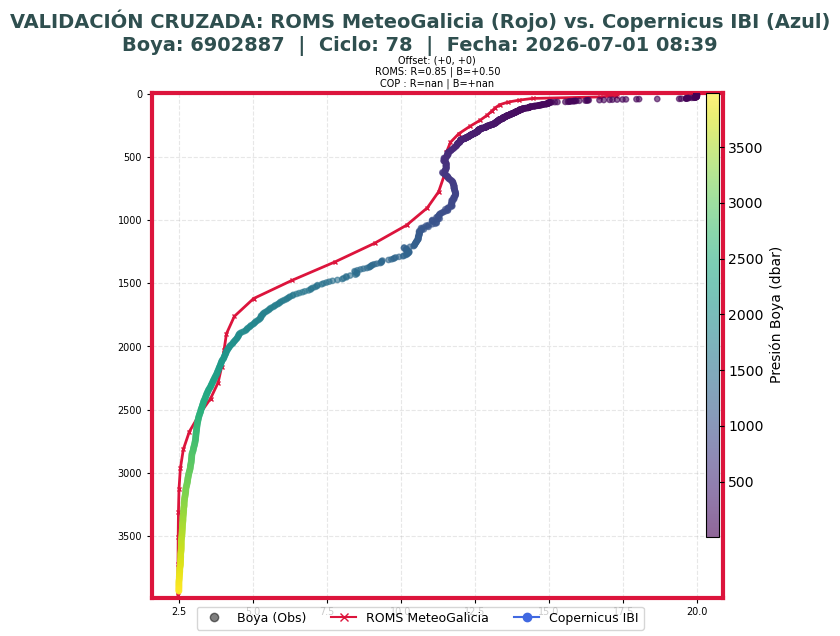

In [10]:
COLOR_ROMS = 'crimson'
COLOR_COPERNICUS = 'royalblue'
centro = N // 2

z_grid_uniforme = np.linspace(0, max(perfil['z_metros']), 100)
f_interp_boya = interp1d(perfil['z_metros'], perfil['TEMP'], kind='linear', bounds_error=False, fill_value=np.nan)
boya_en_grid_unif = f_interp_boya(z_grid_uniforme)

mejor_rmse_roms = float('inf')
mejor_rmse_cop = float('inf')
nodo_top_roms = None
nodo_top_cop = None

for fila in range(N):
    for columna in range(N):
        datos_roms = resultados_roms_matriz.get((fila, columna), None)
        if datos_roms is not None:
            z_roms = datos_roms['z_roms_metros']
            interp_mod_roms = interp1d(z_roms, datos_roms['roms_temp_perfil'], kind='linear', bounds_error=False, fill_value=np.nan)
            r_unif = interp_mod_roms(z_grid_uniforme)
            mask = ~np.isnan(boya_en_grid_unif) & ~np.isnan(r_unif)
            if np.any(mask):
                rmse_r = np.sqrt(np.mean((boya_en_grid_unif[mask] - r_unif[mask])**2))
                if rmse_r < mejor_rmse_roms:
                    mejor_rmse_roms = rmse_r
                    nodo_top_roms = (fila, columna)
        
        datos_cop = resultados_copernicus_matriz.get((fila, columna), None)
        if datos_cop is not None and 'roms_temp_perfil' in datos_cop:
            z_c = datos_cop['z_roms_metros']
            t_c = datos_cop['roms_temp_perfil']
            mask_nan_cop = ~np.isnan(t_c)
            if np.any(mask_nan_cop):
                interp_mod_cop = interp1d(z_c[mask_nan_cop], t_c[mask_nan_cop], kind='linear', bounds_error=False, fill_value=np.nan)
                c_unif = interp_mod_cop(z_grid_uniforme)
                mask = ~np.isnan(boya_en_grid_unif) & ~np.isnan(c_unif)
                if np.any(mask):
                    rmse_c = np.sqrt(np.mean((boya_en_grid_unif[mask] - c_unif[mask])**2))
                    if rmse_c < mejor_rmse_cop:
                        mejor_rmse_cop = rmse_c
                        nodo_top_cop = (fila, columna)

tamano_celda = 6.5 - (N * 0.15)
fig, axes = plt.subplots(N, N, figsize=(N * tamano_celda, N * tamano_celda), sharex=True, sharey=True, squeeze=False)

texto_titulo = (
    f"VALIDACIÓN CRUZADA: ROMS MeteoGalicia (Rojo) vs. Copernicus IBI (Azul)\n"
    f"Boya: {MI_BOYA}  |  Ciclo: {MI_CICLO}  |  Fecha: {fecha_boya.strftime('%Y-%m-%d %H:%M')}"
)
fig.suptitle(texto_titulo, fontsize=14, fontweight='bold', color='darkslategray', y=0.98)

sc = None

for fila in range(N):
    for columna in range(N):
        ax = axes[fila, columna]
        
        if resultados_roms_matriz.get((fila, columna)) is None and resultados_copernicus_matriz.get((fila, columna)) is None:
            ax.text(0.5, 0.5, "Sin Datos", ha='center', va='center', color='gray')
            ax.grid(True, linestyle='--', alpha=0.3)
            continue

        sc = ax.scatter(perfil['TEMP'], perfil['z_metros'], 
                        c=perfil['PRES'], cmap='viridis', alpha=0.6, s=15, zorder=3)
        
        datos_roms = resultados_roms_matriz.get((fila, columna))
        rmse_roms, bias_roms = np.nan, np.nan
        if datos_roms is not None:
            z_r = datos_roms['z_roms_metros']
            idx_r = np.argsort(z_r)
            ax.plot(datos_roms['roms_temp_perfil'][idx_r], z_r[idx_r], color=COLOR_ROMS, linestyle='-', linewidth=2, marker='x', markersize=3)
            
            interp_r = interp1d(z_r[idx_r], datos_roms['roms_temp_perfil'][idx_r], kind='linear', bounds_error=False, fill_value=np.nan)
            r_unif = interp_r(z_grid_uniforme)
            m_r = ~np.isnan(boya_en_grid_unif) & ~np.isnan(r_unif)
            if np.any(m_r):
                rmse_roms = np.sqrt(np.mean((boya_en_grid_unif[m_r] - r_unif[m_r])**2))
                bias_roms = np.mean(boya_en_grid_unif[m_r] - r_unif[m_r])

        datos_cop = resultados_copernicus_matriz.get((fila, columna))
        rmse_cop, bias_cop = np.nan, np.nan
        if datos_cop is not None and 'roms_temp_perfil' in datos_cop:
            z_c = datos_cop['z_roms_metros']
            temp_c = datos_cop['roms_temp_perfil']
            mask_nan_cop = ~np.isnan(temp_c)
            if np.any(mask_nan_cop):
                z_c_valid = z_c[mask_nan_cop]
                temp_c_valid = temp_c[mask_nan_cop]
                idx_c = np.argsort(z_c_valid)
                ax.plot(temp_c_valid[idx_c], z_c_valid[idx_c], color=COLOR_COPERNICUS, linestyle='-', linewidth=2, marker='o', markersize=3)
                
                interp_c = interp1d(z_c_valid[idx_c], temp_c_valid[idx_c], kind='linear', bounds_error=False, fill_value=np.nan)
                c_unif = interp_c(z_grid_uniforme)
                m_c = ~np.isnan(boya_en_grid_unif) & ~np.isnan(c_unif)
                if np.any(m_c):
                    rmse_cop = np.sqrt(np.mean((boya_en_grid_unif[m_c] - c_unif[m_c])**2))
                    bias_cop = np.mean(boya_en_grid_unif[m_c] - c_unif[m_c])

        txt_stats = (f"Offset: ({centro - fila:+,}, {columna - centro:+,})\n"
                     f"ROMS: R={rmse_roms:.2f} | B={bias_roms:+.2f}\n"
                     f"COP : R={rmse_cop:.2f} | B={bias_cop:+.2f}")
        ax.set_title(txt_stats, fontsize=7, pad=4)
        
        es_top_roms = ((fila, columna) == nodo_top_roms)
        es_top_cop = ((fila, columna) == nodo_top_cop)
        
        if es_top_roms or es_top_cop:
            for spine in ax.spines.values(): spine.set_linewidth(3.0)
            if es_top_roms and es_top_cop:
                ax.spines['top'].set_color(COLOR_ROMS); ax.spines['left'].set_color(COLOR_ROMS)
                ax.spines['bottom'].set_color(COLOR_COPERNICUS); ax.spines['right'].set_color(COLOR_COPERNICUS)
            elif es_top_roms:
                for spine in ax.spines.values(): spine.set_color(COLOR_ROMS)
            elif es_top_cop:
                for spine in ax.spines.values(): spine.set_color(COLOR_COPERNICUS)

        ax.invert_yaxis()
        ax.grid(True, linestyle='--', alpha=0.3)
        ax.tick_params(labelsize=7)

for ax in axes.flat: ax.set_ylim(max(perfil['z_metros']) + 50, -10)
plt.tight_layout()
fig.subplots_adjust(top=0.85, bottom=0.1, right=0.93)

leyenda = [
    plt.Line2D([0], [0], color='black', marker='o', linestyle='', alpha=0.5, label="Boya (Obs)"),
    plt.Line2D([0], [0], color=COLOR_ROMS, marker='x', label="ROMS MeteoGalicia"),
    plt.Line2D([0], [0], color=COLOR_COPERNICUS, marker='o', label="Copernicus IBI")
]
fig.legend(handles=leyenda, loc='lower center', ncol=3, fontsize=9)

cbar_ax = fig.add_axes([0.95, 0.15, 0.02, 0.7])
fig.colorbar(sc, cax=cbar_ax, label='Presión Boya (dbar)')
plt.tight_layout()
fig.subplots_adjust(top=0.85)
plt.savefig(f"graficos_validacion/boya_{MI_BOYA}/ciclo_{MI_CICLO}/temperatura_{N}x{N}.png", dpi=300, bbox_inches='tight')
plt.show()

In [11]:
# INSPECCIÓN DE CLAVES DE COPERNICUS
primer_nodo_cop = next((v for v in resultados_copernicus_matriz.values() if v is not None), None)
if primer_nodo_cop is not None:
    print("Las claves reales en tu Copernicus son:", list(primer_nodo_cop.keys()))

Las claves reales en tu Copernicus son: ['lat_roms_real', 'lon_roms_real', 'lat_teorica', 'lon_teorica', 'z_roms_metros', 'roms_temp_perfil', 'roms_salt_perfil', 'profundidad_fondo']


/tmp/ipykernel_23338/3755324004.py:188: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


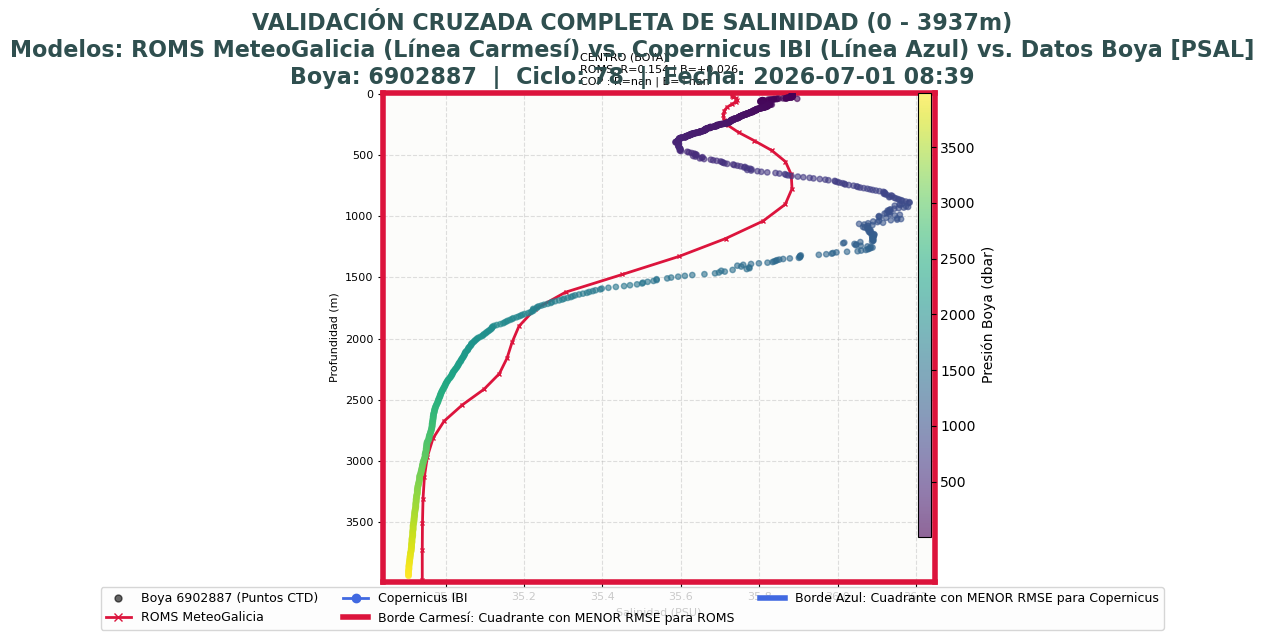

In [12]:
COLOR_ROMS = 'crimson'          
COLOR_COPERNICUS = 'royalblue'  
centro = N // 2

opciones_boya = ['PSAL', 'SAL', 'salinity', 'sal', 'SALINIDAD', 'Sal']
COL_SAL_BOYA = next((col for col in opciones_boya if col in perfil.columns), 'PSAL')

primer_nodo_roms = next((v for v in resultados_roms_matriz.values() if v is not None), {})
KEY_SAL_ROMS = next((k for k in ['roms_sal_perfil', 'roms_salt_perfil'] if k in primer_nodo_roms), 'roms_sal_perfil')

primer_nodo_cop = next((v for v in resultados_copernicus_matriz.values() if v is not None), {})
KEY_SAL_COP = next((k for k in ['roms_salt_perfil', 'roms_sal_perfil'] if k in primer_nodo_cop), 'roms_salt_perfil')

# Datos reales de la boya
boya_sal = perfil[COL_SAL_BOYA].values
profundidades_boya = perfil['z_metros'].values
indices_boya_ordenados = np.argsort(profundidades_boya)

max_prof_boya = profundidades_boya.max()

# Interpolado de la boya
funcion_interp_boya = interp1d(
    profundidades_boya[indices_boya_ordenados], 
    boya_sal[indices_boya_ordenados], 
    kind='linear', 
    bounds_error=False, 
    fill_value=np.nan
)

# Eje vertical uniforme de 0 a 2000m para evaluación del RMSE
z_grid_uniforme = np.linspace(0, max_prof_boya, 100)
boya_en_grid_unif = funcion_interp_boya(z_grid_uniforme)

mejor_rmse_roms = float('inf')
mejor_rmse_cop = float('inf')
nodo_top_roms = None
nodo_top_cop = None

for fila in range(N):
    for columna in range(N):
        datos_roms = resultados_roms_matriz.get((fila, columna), None)
        if datos_roms is not None and KEY_SAL_ROMS in datos_roms:
            z_roms_ord = datos_roms['z_roms_metros'][np.argsort(datos_roms['z_roms_metros'])]
            sal_roms_ord = datos_roms[KEY_SAL_ROMS][np.argsort(datos_roms['z_roms_metros'])]
            
            interp_mod_roms = interp1d(z_roms_ord, sal_roms_ord, kind='linear', bounds_error=False, fill_value=np.nan)
            roms_en_grid_unif = interp_mod_roms(z_grid_uniforme)
            
            mask = ~np.isnan(boya_en_grid_unif) & ~np.isnan(roms_en_grid_unif)
            if np.any(mask):
                rmse_r = np.sqrt(np.mean((boya_en_grid_unif[mask] - roms_en_grid_unif[mask])**2))
                if rmse_r < mejor_rmse_roms:
                    mejor_rmse_roms = rmse_r
                    nodo_top_roms = (fila, columna)
                
        datos_cop = resultados_copernicus_matriz.get((fila, columna), None)
        if datos_cop is not None and KEY_SAL_COP in datos_cop:
            mask_nan_cop = ~np.isnan(datos_cop[KEY_SAL_COP])
            if np.any(mask_nan_cop):
                z_cop_ord = datos_cop['z_roms_metros'][mask_nan_cop][np.argsort(datos_cop['z_roms_metros'][mask_nan_cop])]
                sal_cop_ord = datos_cop[KEY_SAL_COP][mask_nan_cop][np.argsort(datos_cop['z_roms_metros'][mask_nan_cop])]
                
                interp_mod_cop = interp1d(z_cop_ord, sal_cop_ord, kind='linear', bounds_error=False, fill_value=np.nan)
                cop_en_grid_unif = interp_mod_cop(z_grid_uniforme)
                
                mask = ~np.isnan(boya_en_grid_unif) & ~np.isnan(cop_en_grid_unif)
                if np.any(mask):
                    rmse_c = np.sqrt(np.mean((boya_en_grid_unif[mask] - cop_en_grid_unif[mask])**2))
                    if rmse_c < mejor_rmse_cop:
                        mejor_rmse_cop = rmse_c
                        nodo_top_cop = (fila, columna)

tamano_celda = 6.5 - (N * 0.15)
fig, axes = plt.subplots(N, N, figsize=(N * tamano_celda, N * tamano_celda), sharex=True, sharey=True, squeeze=False)

texto_titulo = (
    f"VALIDACIÓN CRUZADA COMPLETA DE SALINIDAD (0 - {max_prof_boya:.0f}m)\n"
    f"Modelos: ROMS MeteoGalicia (Línea Carmesí) vs. Copernicus IBI (Línea Azul) vs. Datos Boya [{COL_SAL_BOYA}]\n"
    f"Boya: {MI_BOYA}  |  Ciclo: {MI_CICLO}  |  Fecha: {fecha_boya.strftime('%Y-%m-%d %H:%M')}"
)
fig.suptitle(texto_titulo, fontsize=16, fontweight='bold', color='darkslategray', y=0.98)

sc = None

for fila in range(N):
    for columna in range(N):
        ax = axes[fila, columna]
        
        if resultados_roms_matriz.get((fila, columna), None) is None and resultados_copernicus_matriz.get((fila, columna), None) is None:
            ax.text(0.5, 0.5, "Sin Datos", ha='center', va='center', color='gray')
            ax.grid(True, linestyle='--', alpha=0.3)
            continue

        sc = ax.scatter(perfil[COL_SAL_BOYA], perfil['z_metros'], 
                        c=perfil['PRES'], cmap='viridis', alpha=0.6, s=15, zorder=3)
        
        datos_roms = resultados_roms_matriz.get((fila, columna), None)
        rmse_roms, bias_roms = np.nan, np.nan
        if datos_roms is not None and KEY_SAL_ROMS in datos_roms:
            z_roms = datos_roms['z_roms_metros']
            idx_r = np.argsort(z_roms)
            z_roms_ord = z_roms[idx_r]
            sal_roms_ord = datos_roms[KEY_SAL_ROMS][idx_r]
            
            ax.plot(sal_roms_ord, z_roms_ord, color=COLOR_ROMS, linestyle='-', linewidth=2, marker='x', markersize=3)
            
            interp_mod_roms = interp1d(z_roms_ord, sal_roms_ord, kind='linear', bounds_error=False, fill_value=np.nan)
            r_unif = interp_mod_roms(z_grid_uniforme)
            m_r = ~np.isnan(boya_en_grid_unif) & ~np.isnan(r_unif)
            if np.any(m_r):
                rmse_roms = np.sqrt(np.mean((boya_en_grid_unif[m_r] - r_unif[m_r])**2))
                bias_roms = np.mean(boya_en_grid_unif[m_r] - r_unif[m_r])

        datos_cop = resultados_copernicus_matriz.get((fila, columna), None)
        rmse_cop, bias_cop = np.nan, np.nan
        if datos_cop is not None and KEY_SAL_COP in datos_cop:
            mask_nan_cop = ~np.isnan(datos_cop[KEY_SAL_COP])
            if np.any(mask_nan_cop):
                z_cop_filt = datos_cop['z_roms_metros'][mask_nan_cop]
                sal_cop_filt = datos_cop[KEY_SAL_COP][mask_nan_cop]
                idx_c = np.argsort(z_cop_filt)
                z_cop_ord = z_cop_filt[idx_c]
                sal_cop_ord = sal_cop_filt[idx_c]
                
                ax.plot(sal_cop_ord, z_cop_ord, color=COLOR_COPERNICUS, linestyle='-', linewidth=2, marker='o', markersize=3)
                
                interp_mod_cop = interp1d(z_cop_ord, sal_cop_ord, kind='linear', bounds_error=False, fill_value=np.nan)
                c_unif = interp_mod_cop(z_grid_uniforme)
                m_c = ~np.isnan(boya_en_grid_unif) & ~np.isnan(c_unif)
                if np.any(m_c):
                    rmse_cop = np.sqrt(np.mean((boya_en_grid_unif[m_c] - c_unif[m_c])**2))
                    bias_cop = np.mean(boya_en_grid_unif[m_c] - c_unif[m_c])

        if fila == centro and columna == centro:
            nombre_sitio = "CENTRO (BOYA)"
            ax.set_facecolor('#fcfcfa')
        else:
            nombre_sitio = f"Offset: ({centro - fila:+,}, {columna - centro:+,})"
            
        txt_stats = (
            f"{nombre_sitio}\n"
            f"ROMS: R={rmse_roms:.3f} | B={bias_roms:+.3f}\n"
            f"COP : R={rmse_cop:.3f} | B={bias_cop:+.3f}"
        )
        ax.set_title(txt_stats, fontsize=8, pad=6, multialignment='left')
        
        es_top_roms = ((fila, columna) == nodo_top_roms)
        es_top_cop = ((fila, columna) == nodo_top_cop)
        
        if es_top_roms or es_top_cop:
            for spine in ax.spines.values():
                spine.set_linewidth(4.0)
            
            if es_top_roms and es_top_cop:
                ax.spines['top'].set_color(COLOR_ROMS)
                ax.spines['left'].set_color(COLOR_ROMS)
                ax.spines['bottom'].set_color(COLOR_COPERNICUS)
                ax.spines['right'].set_color(COLOR_COPERNICUS)
            elif es_top_roms:
                for spine in ax.spines.values(): spine.set_color(COLOR_ROMS)
            elif es_top_cop:
                for spine in ax.spines.values(): spine.set_color(COLOR_COPERNICUS)

        ax.invert_yaxis()  
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.tick_params(labelbottom=True, labelleft=True, labelsize=8) 
        ax.set_xlabel('Salinidad (PSU)', fontsize=8)
        ax.set_ylabel('Profundidad (m)', fontsize=8)

for row in axes:
    for ax in row:
        ax.set_ylim(max_prof_boya + 50, -10)

plt.tight_layout()
fig.subplots_adjust(top=0.88, bottom=0.08, right=0.93)

lineas_leyenda = [
    plt.Line2D([0], [0], color='black', marker='o', markersize=5, linestyle='', alpha=0.6, label=f"Boya {MI_BOYA} (Puntos CTD)"),
    plt.Line2D([0], [0], color=COLOR_ROMS, linestyle='-', linewidth=2, marker='x', label="ROMS MeteoGalicia"),
    plt.Line2D([0], [0], color=COLOR_COPERNICUS, linestyle='-', linewidth=2, marker='o', label="Copernicus IBI"),
    plt.Line2D([0], [0], color=COLOR_ROMS, linewidth=4, label="Borde Carmesí: Cuadrante con MENOR RMSE para ROMS"),
    plt.Line2D([0], [0], color=COLOR_COPERNICUS, linewidth=4, label="Borde Azul: Cuadrante con MENOR RMSE para Copernicus")
]
fig.legend(handles=lineas_leyenda, loc='lower center', ncol=3, fontsize=9, frameon=True, facecolor='#fdfdfd')

cbar_ax = fig.add_axes([0.95, 0.15, 0.02, 0.7])
fig.colorbar(sc, cax=cbar_ax, label='Presión Boya (dbar)')
plt.tight_layout()
fig.subplots_adjust(top=0.85)
plt.savefig(f"graficos_validacion/boya_{MI_BOYA}/ciclo_{MI_CICLO}/salinidad_{N}x{N}.png", dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_23338/3352368192.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


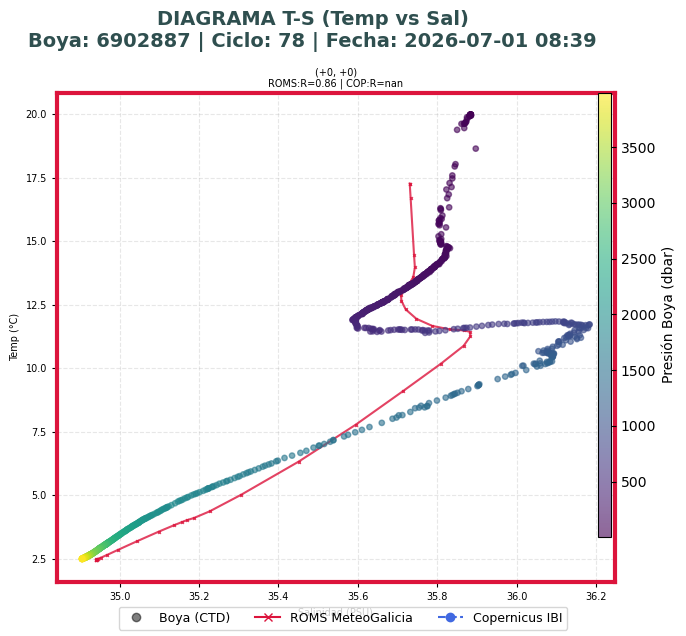

In [13]:
COLOR_ROMS = 'crimson'
COLOR_COPERNICUS = 'royalblue'
centro = N // 2

max_prof_boya = perfil['z_metros'].max()
z_grid_uniforme = np.linspace(0, max_prof_boya, 100)

# Interpoladores de la boya (usando columnas reales 'TEMP' y 'PSAL')
f_interp_t_boya = interp1d(perfil['z_metros'], perfil['TEMP'], kind='linear', bounds_error=False, fill_value=np.nan)
f_interp_s_boya = interp1d(perfil['z_metros'], perfil['PSAL'], kind='linear', bounds_error=False, fill_value=np.nan)

# Estas son las variables que necesita el loop de cálculo
temp_boya_unif = f_interp_t_boya(z_grid_uniforme)
psal_boya_unif = f_interp_s_boya(z_grid_uniforme)

tamano_celda = 6.5 - (N * 0.15)
fig, axes = plt.subplots(N, N, figsize=(N * tamano_celda, N * tamano_celda), squeeze=False)

texto_titulo = (f"DIAGRAMA T-S (Temp vs Sal)\n"
                f"Boya: {MI_BOYA} | Ciclo: {MI_CICLO} | Fecha: {fecha_boya.strftime('%Y-%m-%d %H:%M')}")
fig.suptitle(texto_titulo, fontsize=14, fontweight='bold', color='darkslategray', y=0.98)

sc = None
for fila in range(N):
    for columna in range(N):
        ax = axes[fila, columna]
        
        sc = ax.scatter(perfil['PSAL'], perfil['TEMP'], 
                        c=perfil['PRES'], cmap='viridis', alpha=0.6, s=15, zorder=3)
 
        datos_roms = resultados_roms_matriz.get((fila, columna))
        rmse_roms_plot = np.nan
        if datos_roms is not None:
            ax.plot(datos_roms['roms_salt_perfil'], datos_roms['roms_temp_perfil'], 
                    color=COLOR_ROMS, linewidth=1.5, alpha=0.8, marker='x', markersize=2)
            
            f_temp = interp1d(datos_roms['z_roms_metros'], datos_roms['roms_temp_perfil'], kind='linear', bounds_error=False)(z_grid_uniforme)
            f_psal = interp1d(datos_roms['z_roms_metros'], datos_roms['roms_salt_perfil'], kind='linear', bounds_error=False)(z_grid_uniforme)
            
            mask = ~np.isnan(temp_boya_unif) & ~np.isnan(f_temp)
            if np.any(mask): 
                rmse_roms_plot = np.sqrt(np.mean((temp_boya_unif[mask] - f_temp[mask])**2 + (psal_boya_unif[mask] - f_psal[mask])**2))

        datos_cop = resultados_copernicus_matriz.get((fila, columna))
        rmse_cop_plot = np.nan
        if datos_cop is not None:
            ax.plot(datos_cop['roms_salt_perfil'], datos_cop['roms_temp_perfil'], 
                    color=COLOR_COPERNICUS, linewidth=1.5, alpha=0.8, linestyle='--', marker='o', markersize=2)
            
            f_temp = interp1d(datos_cop['z_roms_metros'], datos_cop['roms_temp_perfil'], kind='linear', bounds_error=False)(z_grid_uniforme)
            f_psal = interp1d(datos_cop['z_roms_metros'], datos_cop['roms_salt_perfil'], kind='linear', bounds_error=False)(z_grid_uniforme)
            
            mask = ~np.isnan(temp_boya_unif) & ~np.isnan(f_temp)
            if np.any(mask): 
                rmse_cop_plot = np.sqrt(np.mean((temp_boya_unif[mask] - f_temp[mask])**2 + (psal_boya_unif[mask] - f_psal[mask])**2))

        ax.set_title(f"({centro-fila:+,}, {columna-centro:+})\nROMS:R={rmse_roms_plot:.2f} | COP:R={rmse_cop_plot:.2f}", fontsize=7, pad=4)

        es_top_roms = ((fila, columna) == nodo_top_roms)
        es_top_cop = ((fila, columna) == nodo_top_cop)
        if es_top_roms or es_top_cop:
            for spine in ax.spines.values(): spine.set_linewidth(3.0)
            if es_top_roms and es_top_cop:
                ax.spines['top'].set_color(COLOR_ROMS); ax.spines['left'].set_color(COLOR_ROMS)
                ax.spines['bottom'].set_color(COLOR_COPERNICUS); ax.spines['right'].set_color(COLOR_COPERNICUS)
            elif es_top_roms: [s.set_color(COLOR_ROMS) for s in ax.spines.values()]
            elif es_top_cop: [s.set_color(COLOR_COPERNICUS) for s in ax.spines.values()]

        ax.grid(True, linestyle='--', alpha=0.3)
        ax.set_xlabel('Salinidad (PSU)', fontsize=7)
        ax.set_ylabel('Temp (°C)', fontsize=7)
        ax.tick_params(labelsize=7)

plt.tight_layout(rect=[0, 0.05, 1, 0.95], h_pad=2.5)
fig.subplots_adjust(top=0.85, bottom=0.1, right=0.93)

leyenda = [
    plt.Line2D([0], [0], color='black', marker='o', linestyle='', alpha=0.5, label="Boya (CTD)"),
    plt.Line2D([0], [0], color=COLOR_ROMS, marker='x', label="ROMS MeteoGalicia"),
    plt.Line2D([0], [0], color=COLOR_COPERNICUS, marker='o', linestyle='--', label="Copernicus IBI")
]
fig.legend(handles=leyenda, loc='lower center', ncol=3, fontsize=9)

cbar_ax = fig.add_axes([0.95, 0.15, 0.02, 0.7])
fig.colorbar(sc, cax=cbar_ax, label='Presión Boya (dbar)')
plt.tight_layout()
fig.subplots_adjust(top=0.85)
plt.savefig(f"graficos_validacion/boya_{MI_BOYA}/ciclo_{MI_CICLO}/diagrama_TS_{N}x{N}.png", dpi=300, bbox_inches='tight')
plt.show()

Comparación estadística (RMSE y bias)

In [14]:
centro = N // 2

boya_temp = perfil['TEMP'].values
boya_salt = perfil['PSAL'].values
profundidades_boya = perfil['z_metros'].values

# Contenedor para almacenar las métricas de cada nodo
tabla_metricas = []

# Iteramos de forma dinámica sobre los resultados de la matriz
for (fila, columna), datos in resultados_roms_matriz.items():
    z_roms_metros = datos['z_roms_metros']
    roms_temp_perfil = datos['roms_temp_perfil']
    roms_salt_perfil = datos['roms_salt_perfil']
    
    # Ordenación estructural para la interpolación lineal
    indices_ordenados = np.argsort(z_roms_metros)
    z_roms_ordenado = z_roms_metros[indices_ordenados]
    temp_roms_ordenado = roms_temp_perfil[indices_ordenados]
    salt_roms_ordenado = roms_salt_perfil[indices_ordenados]
    
    # Generamos los interpoladores para este nodo específico
    funcion_interp_temp = interp1d(z_roms_ordenado, temp_roms_ordenado, kind='linear', fill_value="extrapolate")
    funcion_interp_salt = interp1d(z_roms_ordenado, salt_roms_ordenado, kind='linear', fill_value="extrapolate")
    
    # Interpolamos el modelo a las profundidades exactas que midió la boya
    roms_temp_interp = funcion_interp_temp(profundidades_boya)
    roms_salt_interp = funcion_interp_salt(profundidades_boya)
    
    error_temp = boya_temp - roms_temp_interp
    error_salt = boya_salt - roms_salt_interp
    
    # Estadísticos globales del perfil del nodo
    rmse_temp = np.sqrt(np.mean(error_temp**2))
    bias_temp = np.mean(error_temp)
    rmse_salt = np.sqrt(np.mean(error_salt**2))
    bias_salt = np.mean(error_salt)
    
    # Offsets geográficos
    offset_lat = centro - fila
    offset_lon = columna - centro
    etiqueta = "CENTRO" if (fila == centro and columna == centro) else f"Offset ({offset_lat:+,}, {offset_lon:+,})"
    
    # Guardamos el registro
    tabla_metricas.append({
        'Fila': fila, 'Columna': columna, 'Nodo': etiqueta,
        'RMSE_T (°C)': rmse_temp, 'Bias_T (°C)': bias_temp,
        'RMSE_S': rmse_salt, 'Bias_S': bias_salt
    })

df_metricas = pd.DataFrame(tabla_metricas)

mejor_nodo_temp = df_metricas.loc[df_metricas['RMSE_T (°C)'].idxmin()]
mejor_nodo_salt = df_metricas.loc[df_metricas['RMSE_S'].idxmin()]

print("-" * 85)
print("                    RESUMEN EJECUTIVO DE SENSIBILIDAD ESPACIAL")
print("-" * 85)
print(f"-> MÍNIMO ERROR TÉRMICO : {mejor_nodo_temp['Nodo']} | RMSE: {mejor_nodo_temp['RMSE_T (°C)']:.4f} °C | Bias: {mejor_nodo_temp['Bias_T (°C)']:.4f} °C")
print(f"-> MÍNIMO ERROR SALINO  : {mejor_nodo_salt['Nodo']} | RMSE: {mejor_nodo_salt['RMSE_S']:.4f}      | Bias: {mejor_nodo_salt['Bias_S']:.4f}")
print("-" * 85)
print("Métricas completas de la malla ordenadas por rendimiento térmico (Menor RMSE):")
print(df_metricas[['Nodo', 'RMSE_T (°C)', 'Bias_T (°C)', 'RMSE_S', 'Bias_S']].sort_values(by='RMSE_T (°C)').to_string(index=False))
print("-" * 85)

-------------------------------------------------------------------------------------
                    RESUMEN EJECUTIVO DE SENSIBILIDAD ESPACIAL
-------------------------------------------------------------------------------------
-> MÍNIMO ERROR TÉRMICO : CENTRO | RMSE: 1.0946 °C | Bias: 0.7152 °C
-> MÍNIMO ERROR SALINO  : CENTRO | RMSE: 0.1479      | Bias: 0.0258
-------------------------------------------------------------------------------------
Métricas completas de la malla ordenadas por rendimiento térmico (Menor RMSE):
  Nodo  RMSE_T (°C)  Bias_T (°C)   RMSE_S  Bias_S
CENTRO     1.094636     0.715241 0.147865 0.02583
-------------------------------------------------------------------------------------


Plots de la comparación estadística

-------------------------------------------------------------------------------------
                    RESUMEN EJECUTIVO DE SENSIBILIDAD ESPACIAL
-------------------------------------------------------------------------------------
-> MÍNIMO ERROR TÉRMICO : CENTRO | RMSE: 1.0946 °C | Bias: 0.7152 °C
-> MÍNIMO ERROR SALINO  : CENTRO | RMSE: 0.1479      | Bias: 0.0258
-------------------------------------------------------------------------------------
Métricas completas de la malla ordenadas por rendimiento térmico (Menor RMSE):
  Nodo  RMSE_T (°C)  Bias_T (°C)   RMSE_S  Bias_S
CENTRO     1.094636     0.715241 0.147865 0.02583
-------------------------------------------------------------------------------------


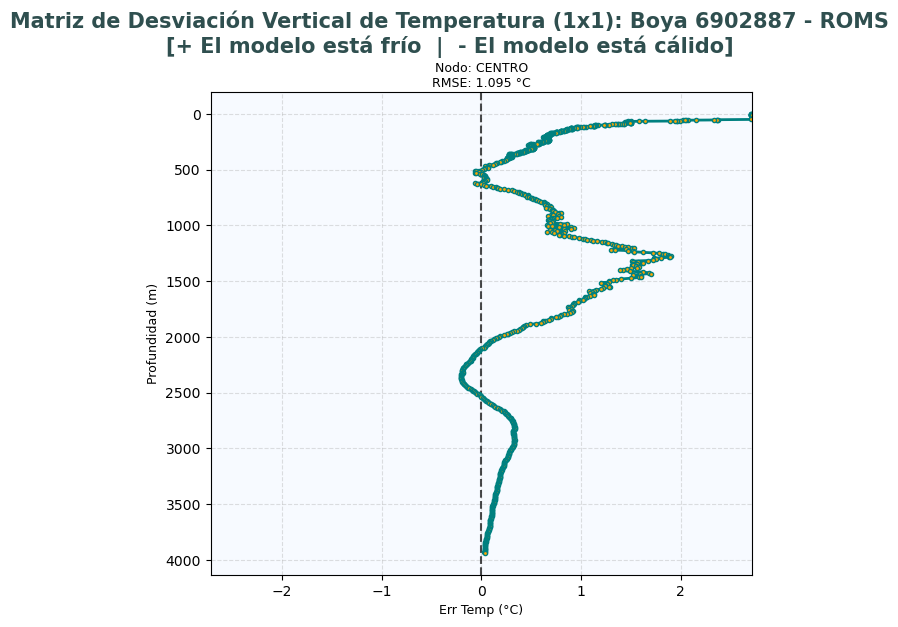

In [15]:
centro = N // 2
boya_temp = perfil['TEMP'].values
boya_salt = perfil['PSAL'].values
profundidades_boya = perfil['z_metros'].values
tabla_metricas = []

for (fila, columna), datos in resultados_roms_matriz.items():
    z_roms_metros = datos['z_roms_metros']
    roms_temp_perfil = datos['roms_temp_perfil']
    roms_salt_perfil = datos['roms_salt_perfil']
    
    indices_ordenados = np.argsort(z_roms_metros)
    z_roms_ordenado = z_roms_metros[indices_ordenados]
    temp_roms_ordenado = roms_temp_perfil[indices_ordenados]
    salt_roms_ordenado = roms_salt_perfil[indices_ordenados]
    
    funcion_interp_temp = interp1d(z_roms_ordenado, temp_roms_ordenado, kind='linear', fill_value="extrapolate")
    funcion_interp_salt = interp1d(z_roms_ordenado, salt_roms_ordenado, kind='linear', fill_value="extrapolate")
    
    roms_temp_interp = funcion_interp_temp(profundidades_boya)
    roms_salt_interp = funcion_interp_salt(profundidades_boya)
    
    error_temp = boya_temp - roms_temp_interp
    error_salt = boya_salt - roms_salt_interp
    
    rmse_temp = np.sqrt(np.mean(error_temp**2))
    bias_temp = np.mean(error_temp)
    rmse_salt = np.sqrt(np.mean(error_salt**2))
    bias_salt = np.mean(error_salt)
    
    offset_lat = centro - fila
    offset_lon = columna - centro
    etiqueta = "CENTRO" if (fila == centro and columna == centro) else f"Offset ({offset_lat:+,}, {offset_lon:+,})"
    
    tabla_metricas.append({
        'Fila': fila, 'Columna': columna, 'Nodo': etiqueta,
        'RMSE_T (°C)': rmse_temp, 'Bias_T (°C)': bias_temp,
        'RMSE_S': rmse_salt, 'Bias_S': bias_salt
    })

df_metricas = pd.DataFrame(tabla_metricas)

mejor_nodo_temp = df_metricas.loc[df_metricas['RMSE_T (°C)'].idxmin()]
mejor_nodo_salt = df_metricas.loc[df_metricas['RMSE_S'].idxmin()]

print("-" * 85)
print("                    RESUMEN EJECUTIVO DE SENSIBILIDAD ESPACIAL")
print("-" * 85)
print(f"-> MÍNIMO ERROR TÉRMICO : {mejor_nodo_temp['Nodo']} | RMSE: {mejor_nodo_temp['RMSE_T (°C)']:.4f} °C | Bias: {mejor_nodo_temp['Bias_T (°C)']:.4f} °C")
print(f"-> MÍNIMO ERROR SALINO  : {mejor_nodo_salt['Nodo']} | RMSE: {mejor_nodo_salt['RMSE_S']:.4f}      | Bias: {mejor_nodo_salt['Bias_S']:.4f}")
print("-" * 85)
print("Métricas completas de la malla ordenadas por rendimiento térmico (Menor RMSE):")
print(df_metricas[['Nodo', 'RMSE_T (°C)', 'Bias_T (°C)', 'RMSE_S', 'Bias_S']].sort_values(by='RMSE_T (°C)').to_string(index=False))
print("-" * 85)

tamano_celda = 6.5 - (N * 0.15)
fig, axes = plt.subplots(N, N, figsize=(N * tamano_celda, N * tamano_celda), sharex=True, sharey=True, squeeze=False)

fig.suptitle(f"Matriz de Desviación Vertical de Temperatura ({N}x{N}): Boya {MI_BOYA} - ROMS\n[+ El modelo está frío  |  - El modelo está cálido]", 
             fontsize=15, fontweight='bold', color='darkslategray', y=0.98)

for fila in range(N):
    for columna in range(N):
        ax = axes[fila, columna]
        datos = resultados_roms_matriz.get((fila, columna), None)
        if datos is None: 
            ax.text(0.5, 0.5, "Sin Datos", ha='center', va='center', color='gray')
            ax.grid(True, linestyle='--', alpha=0.3)
            continue
        
        z_roms_ord = datos['z_roms_metros'][np.argsort(datos['z_roms_metros'])]
        t_roms_ord = datos['roms_temp_perfil'][np.argsort(datos['z_roms_metros'])]
        f_interp = interp1d(z_roms_ord, t_roms_ord, kind='linear', fill_value="extrapolate")
        
        error_temp = boya_temp - f_interp(profundidades_boya)
        
        ax.axvline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
        ax.plot(error_temp, profundidades_boya, color='teal', linestyle='-', linewidth=2, marker='o', ms=3, mfc='orange')
        
        offset_lat, offset_lon = centro - fila, columna - centro
        lbl = "CENTRO" if (fila == centro and columna == centro) else f"({offset_lat:+,}, {offset_lon:+,})"
        if fila == centro and columna == centro: ax.set_facecolor('#f7faff')
            
        ax.set_title(f"Nodo: {lbl}\nRMSE: {np.sqrt(np.mean(error_temp**2)):.3f} °C", fontsize=9, pad=4)
        ax.invert_yaxis()
        ax.grid(True, linestyle='--', alpha=0.4)
        
        ax.tick_params(labelbottom=True, labelleft=True)
        ax.set_xlabel('Err Temp (°C)', fontsize=9)
        ax.set_ylabel('Profundidad (m)', fontsize=9)

limite_x = max(abs(df_metricas['Bias_T (°C)'])) + 2
for ax in axes.flat:
    ax.set_xlim(-limite_x, limite_x)

plt.tight_layout()
fig.subplots_adjust(top=0.85)
plt.savefig(f"graficos_validacion/boya_{MI_BOYA}/ciclo_{MI_CICLO}/matriz_error_temp_{N}x{N}.png", dpi=300)
plt.show()

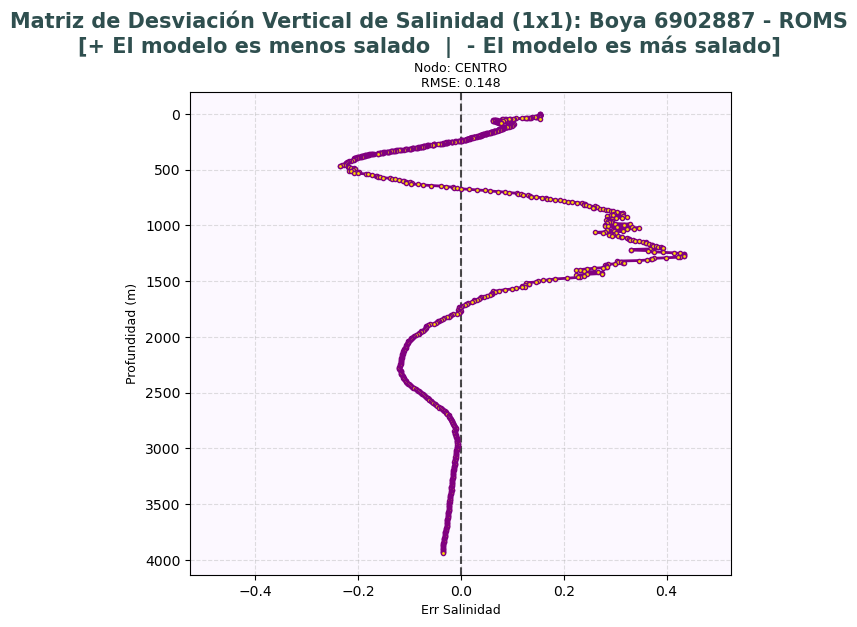

In [16]:
tamano_celda = 6.5 - (N * 0.15)
fig, axes = plt.subplots(N, N, figsize=(N * tamano_celda, N * tamano_celda), sharex=True, sharey=True, squeeze=False)
fig.suptitle(f"Matriz de Desviación Vertical de Salinidad ({N}x{N}): Boya {MI_BOYA} - ROMS\n[+ El modelo es menos salado  |  - El modelo es más salado]", 
             fontsize=15, fontweight='bold', color='darkslategray', y=0.98)

for fila in range(N):
    for columna in range(N):
        ax = axes[fila, columna]
        datos = resultados_roms_matriz.get((fila, columna), None)
        if datos is None: 
            ax.text(0.5, 0.5, "Sin Datos", ha='center', va='center', color='gray')
            ax.grid(True, linestyle='--', alpha=0.3)
            continue
        
        z_roms_ord = datos['z_roms_metros'][np.argsort(datos['z_roms_metros'])]
        s_roms_ord = datos['roms_salt_perfil'][np.argsort(datos['z_roms_metros'])]
        f_interp = interp1d(z_roms_ord, s_roms_ord, kind='linear', fill_value="extrapolate")
        
        error_salt = boya_salt - f_interp(profundidades_boya)
        
        ax.axvline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
        ax.plot(error_salt, profundidades_boya, color='purple', linestyle='-', linewidth=2, marker='o', ms=3, mfc='gold')
        
        offset_lat, offset_lon = centro - fila, columna - centro
        lbl = "CENTRO" if (fila == centro and columna == centro) else f"({offset_lat:+,}, {offset_lon:+,})"
        if fila == centro and columna == centro: ax.set_facecolor('#fcf8ff')
            
        ax.set_title(f"Nodo: {lbl}\nRMSE: {np.sqrt(np.mean(error_salt**2)):.3f}", fontsize=9, pad=4)
        ax.invert_yaxis()
        ax.grid(True, linestyle='--', alpha=0.4)
        
        ax.tick_params(labelbottom=True, labelleft=True) 
        ax.set_xlabel('Err Salinidad', fontsize=9)       
        ax.set_ylabel('Profundidad (m)', fontsize=9)     

limite_x = max(abs(df_metricas['Bias_S'])) + 0.5
axes[0, 0].set_xlim(-limite_x, limite_x)

plt.tight_layout()
fig.subplots_adjust(top=0.85)
plt.savefig(f"graficos_validacion/boya_{MI_BOYA}/ciclo_{MI_CICLO}/matriz_error_salt_{N}x{N}.png", dpi=300)
plt.show()

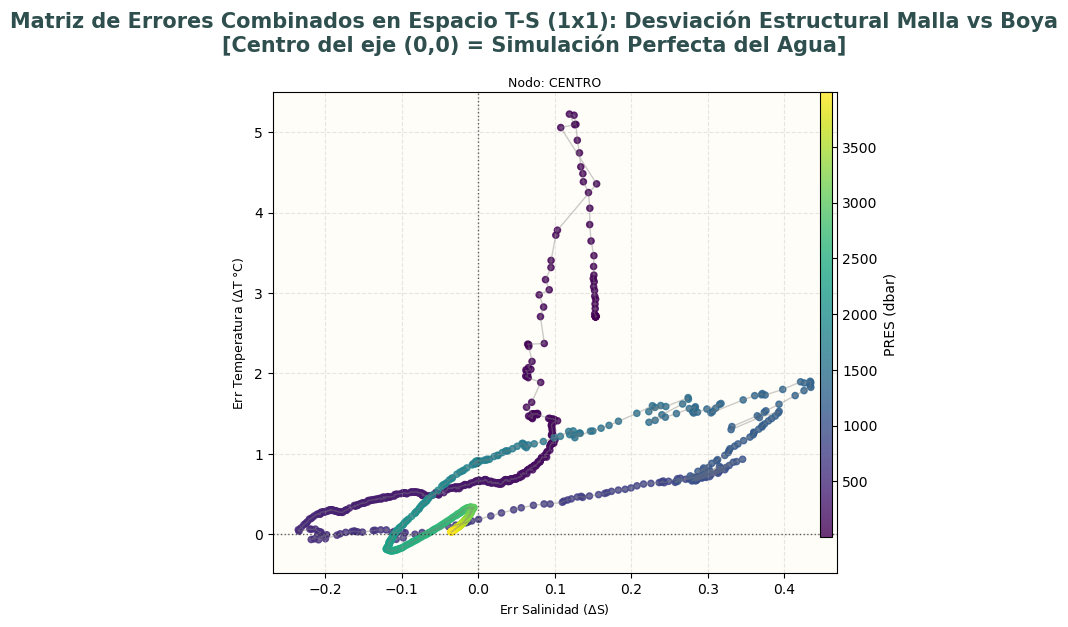

In [17]:
tamano_celda = 6.5 - (N * 0.15)
fig, axes = plt.subplots(N, N, figsize=(N * tamano_celda, N * tamano_celda), sharex=True, sharey=True, squeeze=False)
fig.suptitle(f"Matriz de Errores Combinados en Espacio T-S ({N}x{N}): Desviación Estructural Malla vs Boya\n[Centro del eje (0,0) = Simulación Perfecta del Agua]", 
             fontsize=15, fontweight='bold', color='darkslategray', y=0.98)

sc = None
for fila in range(N):
    for columna in range(N):
        ax = axes[fila, columna]
        datos = resultados_roms_matriz.get((fila, columna), None)
        if datos is None: 
            ax.text(0.5, 0.5, "Sin Datos", ha='center', va='center', color='gray')
            ax.grid(True, linestyle='--', alpha=0.3)
            continue
        
        z_roms_ord = datos['z_roms_metros'][np.argsort(datos['z_roms_metros'])]
        f_int_t = interp1d(z_roms_ord, datos['roms_temp_perfil'][np.argsort(datos['z_roms_metros'])], kind='linear', fill_value="extrapolate")
        f_int_s = interp1d(z_roms_ord, datos['roms_salt_perfil'][np.argsort(datos['z_roms_metros'])], kind='linear', fill_value="extrapolate")
        
        error_temp = boya_temp - f_int_t(profundidades_boya)
        error_salt = boya_salt - f_int_s(profundidades_boya)
        
        ax.axvline(0, color='black', linestyle=':', alpha=0.6, linewidth=1)
        ax.axhline(0, color='black', linestyle=':', alpha=0.6, linewidth=1)
        
        ax.plot(error_salt, error_temp, color='gray', linestyle='-', linewidth=1, alpha=0.4)
        sc = ax.scatter(error_salt, error_temp, c=perfil['PRES'], cmap='viridis', alpha=0.8, s=20)
        
        offset_lat, offset_lon = centro - fila, columna - centro
        lbl = "CENTRO" if (fila == centro and columna == centro) else f"({offset_lat:+,}, {offset_lon:+,})"
        if fila == centro and columna == centro: ax.set_facecolor('#fffdf7')
            
        ax.set_title(f"Nodo: {lbl}", fontsize=9, pad=4)
        ax.grid(True, linestyle='--', alpha=0.3)
        
        ax.tick_params(labelbottom=True, labelleft=True) 
        ax.set_xlabel(r'Err Salinidad ($\Delta$S)', fontsize=9)       
        ax.set_ylabel(r'Err Temperatura ($\Delta$T °C)', fontsize=9)     

plt.tight_layout()
fig.subplots_adjust(top=0.85)

cbar_ax = fig.add_axes([0.95, 0.15, 0.02, 0.7])
fig.colorbar(sc, cax=cbar_ax, label='PRES (dbar)')

plt.savefig(f"graficos_validacion/boya_{MI_BOYA}/ciclo_{MI_CICLO}/matriz_error_TS_{N}x{N}.png", dpi=300)
plt.show()